# H2 spatial analysis
Run the notebook from top to bottom. It produces the H2 tables and spatial figures used in the dissertation.

## Data and reproducibility

This notebook uses repository-relative paths only. To reproduce the results:

1. Clone the repository and open Jupyter from the repository root.
2. Install the dependencies: `pip install -r requirements.txt`
3. Run the notebook from top to bottom (Kernel -> Restart & Run All).

The two input files are larger than the GitHub 100 MB file limit and are hosted
externally. The setup cell downloads them automatically into `data/`; if the
automatic download fails, the links in `README.md` allow them to be downloaded
manually. All tables and figures are written to `outputs/`.


## 1. Setup

In [1]:
from pathlib import Path
import json

import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import numpy as np
import pandas as pd
from shapely import wkb
from shapely.geometry import box
from sklearn.cluster import DBSCAN
from libpysal.weights import KNN
from libpysal.weights.spatial_lag import lag_spatial
from esda.moran import Moran

try:
    import contextily as ctx
except ImportError:
    ctx = None
plt.rcParams.update({"font.size": 11, "axes.titlesize": 15, "axes.labelsize": 11})
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)


In [2]:
SEED = 1
rng = np.random.default_rng(SEED)

def find_repo_root(start=None) -> Path:
    here = (start or Path.cwd()).resolve()
    for candidate in [here, *here.parents]:
        if (candidate / ".git").exists() or (candidate / "data").is_dir():
            return candidate
    return here


REPO_ROOT = find_repo_root()
DATA_DIR = REPO_ROOT / "data"
OUT = REPO_ROOT / "outputs"
FIGURE_OUTPUTS = OUT / "publication_figures"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT.mkdir(parents=True, exist_ok=True)
FIGURE_OUTPUTS.mkdir(parents=True, exist_ok=True)

PARQUET = DATA_DIR / "2025-12-31-ho-man-chan-brands-2016-2025.parquet"
LAD_BOUNDARIES = DATA_DIR / "LAD_boundaries.geojson"

GDRIVE_FILE_IDS = {
    "2025-12-31-ho-man-chan-brands-2016-2025.parquet": "18m2_5TOgHP68_HpvJaCUkjliCfqpbZOM",
    "LAD_boundaries.geojson": "REPLACE_WITH_GEOJSON_FILE_ID",
}


def ensure_input(path: Path) -> Path:
    if path.exists():
        return path

    file_id = GDRIVE_FILE_IDS.get(path.name, "")
    if file_id and not file_id.startswith("REPLACE_WITH"):
        try:
            import gdown
        except ImportError:
            import subprocess
            import sys
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install", "--quiet", "gdown"]
            )
            import gdown

        print(f"Downloading {path.name} from Google Drive.")
        try:
            gdown.download(id=file_id, output=str(path), quiet=False)
        except Exception as error:
            print(f"Automatic download failed: {error}")

    if not path.exists():
        raise FileNotFoundError(
            f"Required input file not found: {path}\n"
            "Download it using the link in README.md and place it in the data/ "
            "directory, then re-run this cell."
        )
    return path


ensure_input(PARQUET)
ensure_input(LAD_BOUNDARIES)

BASE = OUT
print("Repository root:", REPO_ROOT)
print("Input panel:    ", PARQUET)
print("LAD boundaries: ", LAD_BOUNDARIES)
print("Outputs:        ", OUT)

DBSCAN_EPS = 400
DBSCAN_MIN_SAMPLES = 3


Repository root: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy
Input panel:     /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/data/2025-12-31-ho-man-chan-brands-2016-2025.parquet
LAD boundaries:  /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/data/LAD_boundaries.geojson
Outputs:         /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs


## 2. Brand definitions and event years

In [3]:
BP = {
 "arcadia": r"arcadia|topshop|top shop|dorothy perkins|miss selfridge|miss selfrid|wallis\b|outfit stores|outfit fashion|outfit retail",
 "wilko": r"\bwilko\b|wilkinson hardware|wl realisations","poundland": r"\bpoundland\b",
 "debenhams": r"debenhams|department stores realisation","bhs": r"\bbhs\b|british home stores",
 "toys r us": r"toys\s*r\s*us","maplin": r"\bmaplin\b","poundworld": r"\bpoundworld\b",
 "thomas cook": r"thomas cook","mothercare": r"\bmothercare\b","paperchase": r"paperchase|aspen phoenix",
 "homebase": r"\bhomebase\b|\bhhgl\b","body shop": r"body shop","ted baker": r"ted baker|no ordinary designer",
 "cath kidston": r"cath kidston","prezzo": r"\bprezzo\b","byron": r"byron hamburger|byron burger|byron restaurants",
 "carluccios": r"carluccio","strada": r"\bstrada\b|strada trading","pizza hut": r"pizza hut",
 "cafe rouge": r"cafe rouge","bella italia": r"bella italia","las iguanas": r"las iguanas",
 "frankie&bennys": r"frankie","chiquito": r"chiquito","brewdog": r"brewdog","franco manca": r"franco ?manca",
 "black sheep": r"black sheep coffe|conilon","blank street": r"\bblank street\b","wasabi": r"\bwasabi\b",
 "select fashion": r"select fashion|genus uk|selbyect",
}
EVT={"bhs":2016,"toys r us":2018,"maplin":2018,"poundworld":2018,"byron":2020,"strada":2018,
 "thomas cook":2019,"mothercare":2019,"arcadia":2020,"carluccios":2020,"chiquito":2020,
 "cath kidston":2020,"frankie&bennys":2020,"cafe rouge":2020,"bella italia":2020,
 "debenhams":2020,"paperchase":2023,"wilko":2023,"prezzo":2018,"body shop":2024,
 "ted baker":2024,"homebase":2024}

## 3. Load data and identify sites

In [4]:
print("Loading VOA panel...")
df=pd.read_parquet(PARQUET,
    columns=['period','geocode_name','uarn','account_name','occupation_state','geometry'])
df['year']=df['period'].astype(str).str[:4].astype(int)
acct=df['account_name'].fillna('').str.lower()
b=pd.Series(index=df.index,dtype='object')
for n,p in BP.items():
    h=acct.str.contains(p,regex=True,na=False); b.loc[h & b.isna()]=n
df['brand']=df['uarn'].map(pd.DataFrame({'uarn':df['uarn'],'b':b}).dropna(subset=['b']).groupby('uarn')['b'].first())

sites=df[df['brand'].notna()].sort_values(['uarn','year']).drop_duplicates('uarn').copy()
sites['geom']=sites['geometry'].apply(lambda h: wkb.loads(bytes.fromhex(h)) if pd.notna(h) else None)
g=gpd.GeoDataFrame(sites.drop(columns='geometry'),geometry='geom',crs='EPSG:4326').to_crs('EPSG:27700')
g=g[g.geometry.notna()].copy()
print("sites:",len(g))

Loading VOA panel...
sites: 3175


## 4. DBSCAN classification

In [5]:
def assign_dbscan(gdf, eps=DBSCAN_EPS):
    out = gdf.copy()
    out["cluster_id"] = pd.Series("noise", index=out.index, dtype="object")
    for authority, sub in out.groupby("geocode_name"):
        if len(sub) < DBSCAN_MIN_SAMPLES:
            continue
        xy = np.column_stack([sub.geometry.x, sub.geometry.y])
        labels = DBSCAN(eps=eps, min_samples=DBSCAN_MIN_SAMPLES).fit_predict(xy)
        labels = pd.Series(labels, index=sub.index)
        for label in sorted(set(labels)):
            if label != -1:
                idx = labels[labels == label].index
                out.loc[idx, "cluster_id"] = f"{authority}_{eps}_{int(label)}"
    out["clustered"] = out["cluster_id"] != "noise"
    return out

sites = assign_dbscan(g)
sites.to_crs("EPSG:4326").to_file(
    OUT / "finding_3_h2_brand_sites_clustered.geojson", driver="GeoJSON"
)
print(f"Clustered at 400m: {sites['clustered'].mean() * 100:.1f}%")

Clustered at 400m: 77.4%


/Users/homanchan/opt/anaconda3/lib/python3.9/site-packages/pyogrio/core.py:35: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


### DBSCAN distance sensitivity

The same sites are reclassified at 250m, 400m and 800m. This cell creates
Table 4.2 and the threshold-sensitivity figure from the current run.


,eps_metres,clustered_sites,isolated_sites,clustered_share,clusters
0,250,2290,885,0.721260,287
1,400,2456,719,0.773543,278
2,800,2700,475,0.850394,268


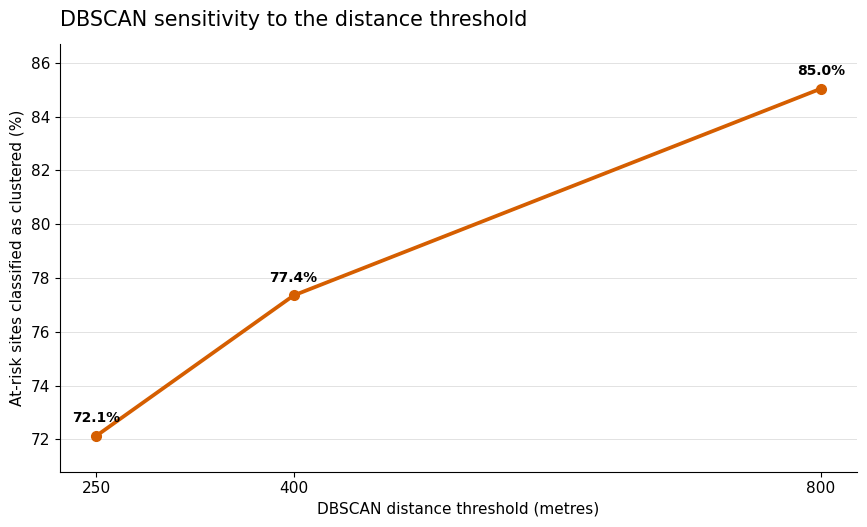

In [6]:
dbscan_rows = []
for radius in [250, 400, 800]:
    classified = assign_dbscan(g, eps=radius)
    clustered = int(classified["clustered"].sum())
    dbscan_rows.append({
        "eps_metres": radius, "clustered_sites": clustered,
        "isolated_sites": int((~classified["clustered"]).sum()),
        "clustered_share": clustered / len(classified),
        "clusters": int(classified.loc[classified["clustered"], "cluster_id"].nunique()),
    })
dbscan_sensitivity = pd.DataFrame(dbscan_rows)
dbscan_sensitivity.to_csv(OUT / "finding_3_h2_dbscan_sensitivity.csv", index=False)
display(dbscan_sensitivity)

fig, ax = plt.subplots(figsize=(8.8, 5.4))
y = dbscan_sensitivity["clustered_share"] * 100
ax.plot(dbscan_sensitivity["eps_metres"], y, color="#D55E00", marker="o", ms=7, lw=2.7)
for row in dbscan_sensitivity.itertuples():
    ax.annotate(f"{row.clustered_share * 100:.1f}%", (row.eps_metres, row.clustered_share * 100),
                xytext=(0, 10), textcoords="offset points", ha="center", fontsize=10, weight="semibold")
ax.set_xticks([250, 400, 800])
ax.set_ylim(70.8, 86.7)
ax.set_xlabel("DBSCAN distance threshold (metres)")
ax.set_ylabel("At-risk sites classified as clustered (%)")
ax.set_title("DBSCAN sensitivity to the distance threshold", loc="left", pad=13)
ax.grid(axis="y", color="#E2E2E2", linewidth=0.7)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
fig.savefig(OUT / "finding_3_h2_dbscan_sensitivity.png", dpi=300, bbox_inches="tight")
plt.show()


### Authority coverage and exposure table

This table supplies the occupation-completeness and distinct-brand values
reported in Chapters 3 and 4.


In [7]:
coverage = (df.groupby("geocode_name")
            .agg(rows=("uarn", "size"),
                 properties=("uarn", "nunique"),
                 years=("year", "nunique"),
                 occupation_completeness=("occupation_state", lambda values: values.notna().mean()))
            .reset_index())
exposure = (sites.groupby("geocode_name")
            .agg(at_risk_sites=("uarn", "nunique"),
                 distinct_at_risk_brands=("brand", "nunique"),
                 clustered_sites=("clustered", "sum"))
            .reset_index())
exposure["isolated_sites"] = exposure["at_risk_sites"] - exposure["clustered_sites"]
exposure["clustered_share"] = exposure["clustered_sites"] / exposure["at_risk_sites"]
authority_coverage = coverage.merge(exposure, on="geocode_name", how="left")
authority_coverage.to_csv(OUT / "finding_1_authority_coverage_reproduced.csv", index=False)

print("Occupation completeness:")
print(authority_coverage["occupation_completeness"].agg(["min", "median", "max"]))
display(authority_coverage.sort_values("at_risk_sites", ascending=False).head(10))
print("Sample geography: 88 authorities with E codes and Cardiff in Wales (W06000015).")


Occupation completeness:
min       0.544681
median    0.891629
max       0.972047
Name: occupation_completeness, dtype: float64


,geocode_name,rows,properties,years,occupation_completeness,at_risk_sites,distinct_at_risk_brands,clustered_sites,isolated_sites,clustered_share
47,Leeds,357319,53438,10,0.804900,119,26,97,22,0.815126
3,Birmingham,538045,76017,10,0.766518,110,23,78,32,0.709091
14,Camden,214431,30254,10,0.891629,103,21,94,9,0.912621
86,West Northamptonshire,136845,19273,10,0.919785,90,18,56,34,0.622222
51,Manchester,311875,48842,10,0.730591,72,25,52,20,0.722222
10,"Bristol, City of",195027,30533,10,0.914837,65,27,47,18,0.723077
5,"Bournemouth, Christchurch and Poole",176173,24243,10,0.924614,64,21,49,15,0.765625
66,Somerset,251930,37984,10,0.859505,63,15,39,24,0.619048
21,Cheshire West and Chester,135035,20118,10,0.715644,61,23,53,8,0.868852
87,Wiltshire,182656,27038,10,0.962087,60,20,50,10,0.833333


Sample geography: 88 authorities with E codes and Cardiff in Wales (W06000015).


## 5. Quadrat VMR and CSR simulation
CSR points are simulated inside the rectangular bounding box of the observed sites in each authority. Authorities require at least 10 sites and at least 500m of spatial extent in both dimensions.

In [8]:
def vmr_for(points_xy, bounds, cell=500.0):
    x0,y0,x1,y1=bounds
    nx=max(int(np.ceil((x1-x0)/cell)),1); ny=max(int(np.ceil((y1-y0)/cell)),1)
    H,_,_=np.histogram2d(points_xy[:,0],points_xy[:,1],bins=[nx,ny],
                         range=[[x0,x0+nx*cell],[y0,y0+ny*cell]])
    c=H.ravel()
    return c.var()/c.mean() if c.mean()>0 else np.nan, nx*ny

In [9]:
rows=[]
for auth,sub in g.groupby('geocode_name'):
    if len(sub)<10: continue
    xy=np.column_stack([sub.geometry.x,sub.geometry.y])
    x0,y0,x1,y1=xy[:,0].min(),xy[:,1].min(),xy[:,0].max(),xy[:,1].max()
    if x1-x0<500 or y1-y0<500: continue
    obs,ncell=vmr_for(xy,(x0,y0,x1,y1))
    sim=[]
    for _ in range(999):
        rx=rng.uniform(x0,x1,len(sub)); ry=rng.uniform(y0,y1,len(sub))
        s,_=vmr_for(np.column_stack([rx,ry]),(x0,y0,x1,y1)); sim.append(s)
    sim=np.array(sim); p=(1+ (sim>=obs).sum())/(1+len(sim))
    rows.append({'authority':auth,'n_sites':len(sub),'quadrats':ncell,
                 'VMR_observed':round(obs,3),'VMR_CSR_mean':round(sim.mean(),3),
                 'p_value':round(p,4),'clustered_p<0.05':p<0.05})
q=pd.DataFrame(rows).sort_values('n_sites',ascending=False)
q.to_csv(OUT / 'finding_h2_quadrat_vmr_csr.csv',index=False)
print(f"authorities tested: {len(q)}  significant clustering (p<0.05): {q['clustered_p<0.05'].sum()} ({q['clustered_p<0.05'].mean()*100:.1f}%)")
print(q.head(12).to_string(index=False))

authorities tested: 86  significant clustering (p<0.05): 86 (100.0%)
                          authority  n_sites  quadrats  VMR_observed  VMR_CSR_mean  p_value  clustered_p<0.05
                              Leeds      119      2112         6.641         1.000    0.001              True
                         Birmingham      110      1419         7.450         1.000    0.001              True
                             Camden      103       140         7.060         1.046    0.001              True
              West Northamptonshire       90      3127         4.149         1.001    0.001              True
                         Manchester       72       630         7.525         1.008    0.001              True
                   Bristol, City of       65       420         6.538         1.001    0.001              True
Bournemouth, Christchurch and Poole       64       400         3.559         1.000    0.001              True
                           Somerset       63     12

## 6. Post-collapse vacancy outcome

In [10]:
# outcome per treated site: post-event vacancy share
ev=g[g['brand'].isin(EVT)].copy(); ev['event_year']=ev['brand'].map(EVT)
obs=df[df['uarn'].isin(ev['uarn'])][['uarn','year','occupation_state']].merge(
    ev[['uarn','event_year']],on='uarn')
obs['t']=obs['year']-obs['event_year']
post=obs[(obs['t']>=0)&(obs['t']<=5)].dropna(subset=['occupation_state'])
post['vac']=post['occupation_state'].eq('VACANT')
site_out=post.groupby('uarn')['vac'].mean().rename('post_vac_share')
sg=ev.merge(site_out,on='uarn')
print("sites with outcome:",len(sg))

sites with outcome: 2095


## 7. Moran's I at site and authority scales
Coincident site coordinates are separated with reproducible 15m random jitter before the site-level KNN weights are built.

In [11]:
# jitter identical coords (shopping centres), seed fixed
jx=sg.geometry.x+rng.normal(0,15,len(sg)); jy=sg.geometry.y+rng.normal(0,15,len(sg))
sg=sg.assign(geometry=gpd.points_from_xy(jx,jy)).set_geometry('geometry')

w_site=KNN.from_dataframe(sg,k=10); w_site.transform='r'
np.random.seed(SEED)
mi_site=Moran(sg['post_vac_share'].values,w_site,permutations=999)

auth=sg.groupby('geocode_name').agg(post_vac_share=('post_vac_share','mean'),
                                    n=('uarn','size')).reset_index()
cent=sg.dissolve(by='geocode_name').centroid
auth=auth.merge(gpd.GeoDataFrame({'geocode_name':cent.index,'geometry':cent.values},crs=sg.crs),
                on='geocode_name')
auth=gpd.GeoDataFrame(auth,geometry='geometry',crs=sg.crs)
w_auth=KNN.from_dataframe(auth,k=6); w_auth.transform='r'
np.random.seed(SEED)
mi_auth=Moran(auth['post_vac_share'].values,w_auth,permutations=999)

/Users/homanchan/opt/anaconda3/lib/python3.9/site-packages/libpysal/weights/weights.py:224: UserWarning: The weights matrix is not fully connected: 
 There are 46 disconnected components.
  warnings.warn(message)


The authority-level weights use centroids calculated from the observed site
geometries within each authority. They do not depend on the LAD polygon file,
so all 89 authorities, including Cardiff, enter this test. Permutation p-values
have minor Monte Carlo variation; the non-significant authority result is
reported as p > 0.4.


In [12]:
mor=pd.DataFrame([
 {'scale':'Site level (k=10)','n':len(sg),"Moran's I":round(mi_site.I,4),
  'E[I]':round(mi_site.EI,4),'p (999 perm)':round(mi_site.p_sim,4),
  'significant p<0.05':mi_site.p_sim<0.05},
 {'scale':'Authority level (k=6)','n':len(auth),"Moran's I":round(mi_auth.I,4),
  'E[I]':round(mi_auth.EI,4),'p (999 perm)':round(mi_auth.p_sim,4),
  'significant p<0.05':mi_auth.p_sim<0.05},
])
mor.to_csv(OUT / 'finding_h2_morans_i_two_scales.csv',index=False)
print(mor.to_string(index=False))

                scale    n  Moran's I    E[I]  p (999 perm)  significant p<0.05
    Site level (k=10) 2095     0.1053 -0.0005         0.001                True
Authority level (k=6)   89    -0.0263 -0.0114         0.451               False


## 8. Formal-test summary figure

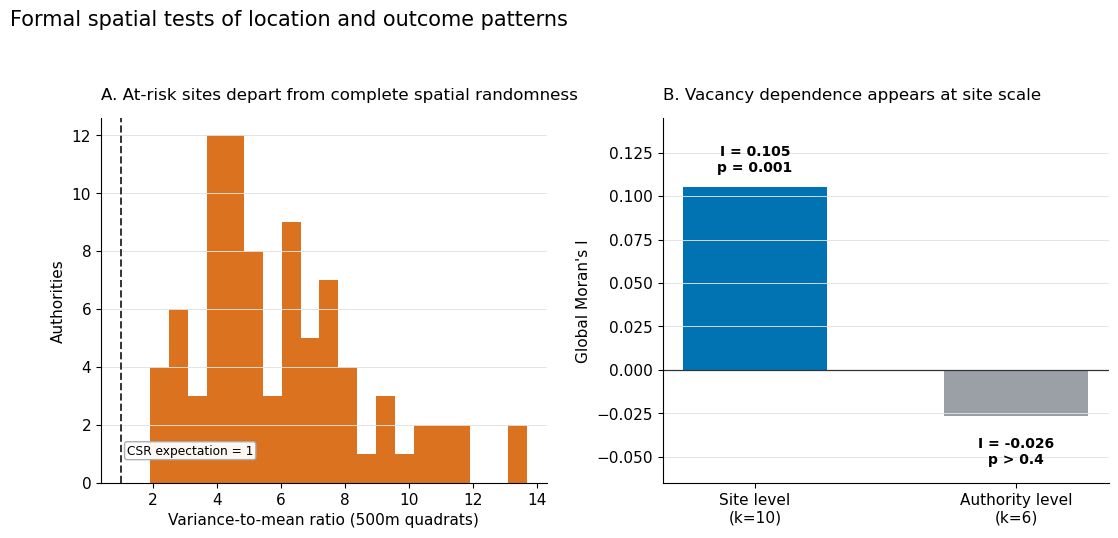

Saved fig_h2_formal_tests.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13.0, 5.7))
ax = axes[0]
ax.hist(q["VMR_observed"], bins=20, color="#D55E00", alpha=0.88)
ax.axvline(1.0, color="#333333", ls="--", lw=1.4)
ylim = ax.get_ylim()
ax.text(1.18, ylim[1] * 0.07, "CSR expectation = 1", fontsize=8.8, ha="left", va="bottom",
        bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "#AAAAAA", "alpha": 0.95})
ax.set_xlabel("Variance-to-mean ratio (500m quadrats)")
ax.set_ylabel("Authorities")
ax.set_title("A. At-risk sites depart from complete spatial randomness", loc="left", pad=13, fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E2E2E2", linewidth=0.65)

ax = axes[1]
values = [mi_site.I, mi_auth.I]
bars = ax.bar(["Site level\n(k=10)", "Authority level\n(k=6)"], values,
              color=["#0173B2", "#9AA0A6"], width=0.55)
labels = [f"I = {mi_site.I:.3f}\np = 0.001", f"I = {mi_auth.I:.3f}\np > 0.4"]
for bar, label, value in zip(bars, labels, values):
    y = value + 0.007 if value >= 0 else value - 0.012
    ax.text(bar.get_x() + bar.get_width()/2, y, label, ha="center",
            va="bottom" if value >= 0 else "top", fontsize=10, weight="semibold")
ax.axhline(0, color="#333333", lw=0.9)
ax.set_ylabel("Global Moran's I")
ax.set_ylim(-0.065, 0.145)
ax.set_title("B. Vacancy dependence appears at site scale", loc="left", pad=13, fontsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E2E2E2", linewidth=0.65)

fig.suptitle("Formal spatial tests of location and outcome patterns", x=0.055, ha="left", fontsize=15)
fig.subplots_adjust(top=0.79, bottom=0.15, wspace=0.26)
fig.savefig(OUT / "fig_h2_formal_tests.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved fig_h2_formal_tests.png")


## 9. Prepare LAD boundaries

In [14]:
with LAD_BOUNDARIES.open(encoding="utf-8") as stream:
    lads_json = json.load(stream)
lads = gpd.GeoDataFrame.from_features(lads_json["features"], crs="EPSG:4326").to_crs("EPSG:27700")

name_candidates = ["LAD24NM", "LAD23NM", "LAD22NM", "LAD21NM", "LADNM", "NAME"]
name_col = next((c for c in name_candidates if c in lads.columns), None)
if name_col is None:
    raise KeyError(f"LAD name column not found: {list(lads.columns)}")
lads = lads.rename(columns={name_col: "geocode_name"})

auth_moran = auth.copy()
auth = (sites.groupby("geocode_name")
        .agg(at_risk_sites=("uarn", "nunique"),
             clustered_sites=("clustered", "sum"))
        .reset_index())
auth["clustered_share_pct"] = auth["clustered_sites"] / auth["at_risk_sites"] * 100
map_gdf = lads.merge(auth, on="geocode_name", how="left")

## 10. National choropleth maps

In [15]:
def plot_lad_choropleth(column, title, legend_label, cmap, output_name, vmin=None, vmax=None):
    fig, ax = plt.subplots(figsize=(8.2, 10.6))
    map_gdf.plot(ax=ax, color="#D9D9D9", edgecolor="white", linewidth=0.20)
    shown = map_gdf[map_gdf[column].notna()]
    shown.plot(column=column, ax=ax, cmap=cmap, edgecolor="white", linewidth=0.30,
               vmin=vmin, vmax=vmax, legend=True,
               legend_kwds={"label": legend_label, "shrink": 0.65, "pad": 0.02})
    minx, miny, maxx, maxy = shown.total_bounds
    ax.set_xlim(minx - 0.025*(maxx-minx), maxx + 0.025*(maxx-minx))
    ax.set_ylim(miny - 0.025*(maxy-miny), maxy + 0.025*(maxy-miny))
    ax.set_aspect("equal")
    ax.set_title(title, loc="left", pad=13)
    ax.set_axis_off()
    fig.tight_layout()
    fig.savefig(FIGURE_OUTPUTS / output_name, dpi=300, bbox_inches="tight")
    plt.show()


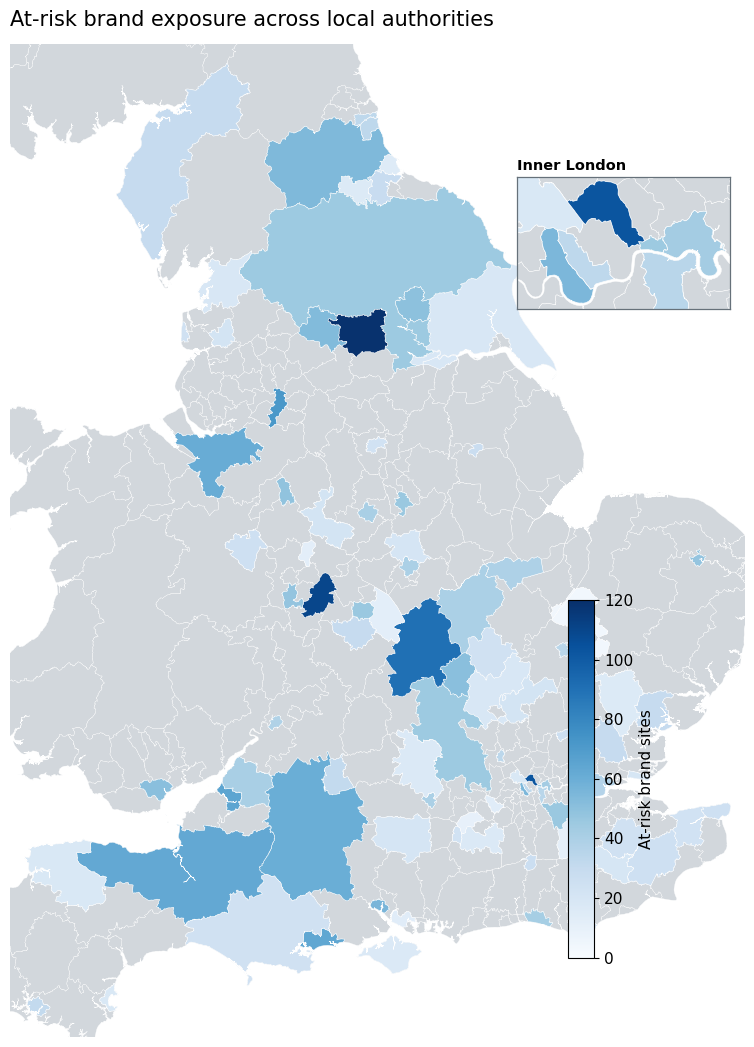

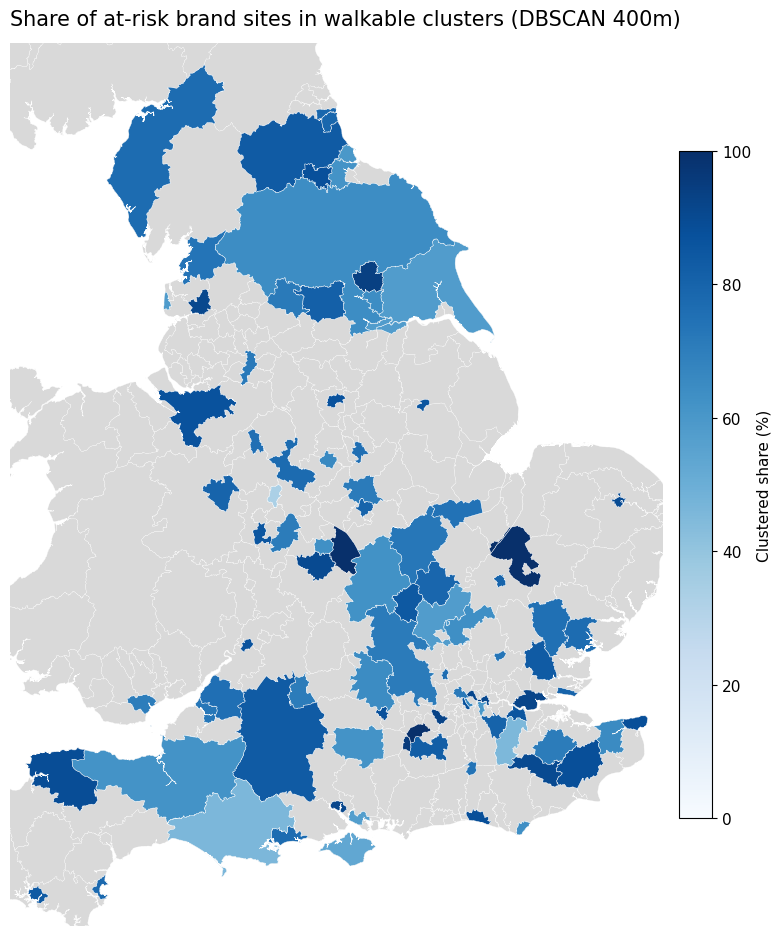

In [16]:
exposure_norm = Normalize(vmin=0, vmax=120)
fig, ax = plt.subplots(figsize=(9.2, 10.6))
map_gdf.plot(ax=ax, color="#D2D7DC", edgecolor="white", linewidth=0.24)
shown = map_gdf[map_gdf["at_risk_sites"].notna()]
shown.plot(column="at_risk_sites", ax=ax, cmap="Blues", norm=exposure_norm,
           edgecolor="white", linewidth=0.34)
minx, miny, maxx, maxy = shown.total_bounds
ax.set_xlim(minx - 0.02*(maxx-minx), maxx + 0.02*(maxx-minx))
ax.set_ylim(miny - 0.02*(maxy-miny), maxy + 0.02*(maxy-miny))
ax.set_aspect("equal")
ax.set_axis_off()

axins = ax.inset_axes([0.69, 0.67, 0.29, 0.26])
map_gdf.plot(ax=axins, color="#D2D7DC", edgecolor="white", linewidth=0.35)
shown.plot(column="at_risk_sites", ax=axins, cmap="Blues", norm=exposure_norm,
           edgecolor="white", linewidth=0.50)
axins.set_xlim(519000, 540000)
axins.set_ylim(175000, 188000)
axins.set_title("Inner London", loc="left", fontsize=10.5, pad=5, weight="semibold")
axins.set_xticks([]); axins.set_yticks([])
for spine in axins.spines.values():
    spine.set_visible(True); spine.set_color("#66717A"); spine.set_linewidth(0.9)

sm = ScalarMappable(norm=exposure_norm, cmap="Blues")
sm.set_array([])
cax = ax.inset_axes([0.76, 0.08, 0.035, 0.36])
cbar = fig.colorbar(sm, cax=cax)
cbar.set_label("At-risk brand sites")
ax.set_title("At-risk brand exposure across local authorities", loc="left", pad=13)
fig.tight_layout()
fig.savefig(FIGURE_OUTPUTS / "main_map_h2_lad_exposure_count.png", dpi=300, bbox_inches="tight")
plt.show()

plot_lad_choropleth(
    "clustered_share_pct", "Share of at-risk brand sites in walkable clusters (DBSCAN 400m)",
    "Clustered share (%)", "Blues", "main_map_h2_lad_clustered_share.png", vmin=0, vmax=100,
)


## 11. Authority-level clustered-share distribution
The main-text cases are highlighted within the full 89-authority distribution. The correlation is descriptive rather than causal.

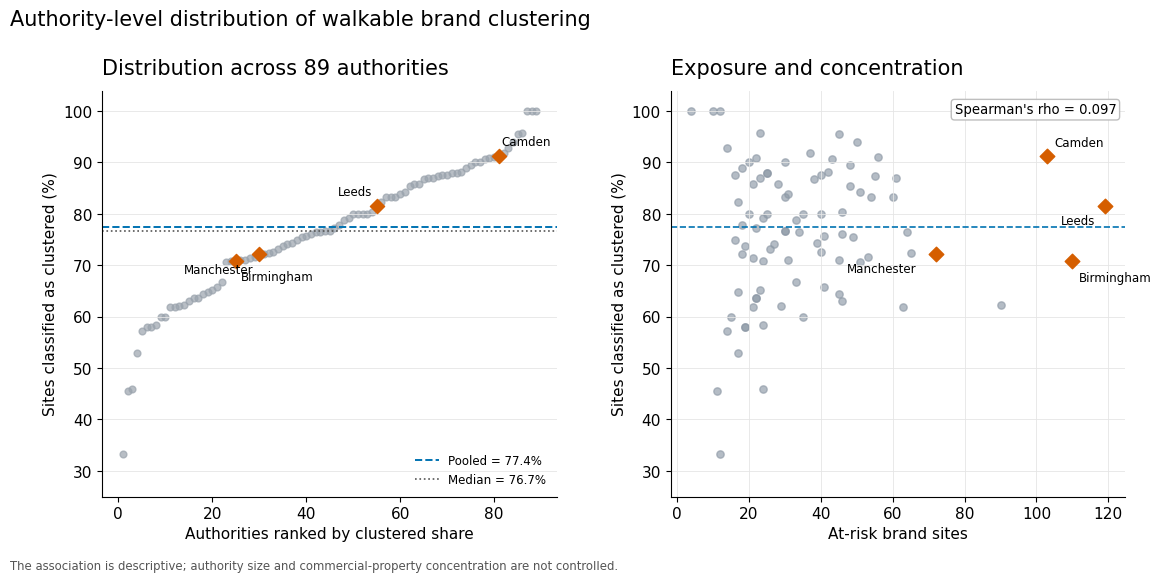

Saved: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs/publication_figures/main_figure_h2_authority_clustered_share_distribution.png
Minimum=33.3%; median=76.7%; mean=76.6%; maximum=100.0%; pooled=77.4%


In [17]:
authority_summary = (sites.groupby("geocode_name")
                     .agg(at_risk_sites=("uarn", "nunique"), clustered_sites=("clustered", "sum"))
                     .reset_index())
authority_summary["clustered_share_pct"] = authority_summary["clustered_sites"] / authority_summary["at_risk_sites"] * 100
pooled_share = sites["clustered"].mean() * 100
median_share = authority_summary["clustered_share_pct"].median()
rho = authority_summary[["at_risk_sites", "clustered_share_pct"]].corr(method="spearman").iloc[0, 1]
main_cases = ["Leeds", "Birmingham", "Camden", "Manchester"]
ordered = authority_summary.sort_values("clustered_share_pct").reset_index(drop=True)
ordered["rank"] = np.arange(1, len(ordered) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13.2, 5.8))
ax = axes[0]
ax.scatter(ordered["rank"], ordered["clustered_share_pct"], color="#9AA3AD", s=24, alpha=0.70)
selected_cases = ordered[ordered["geocode_name"].isin(main_cases)]
ax.scatter(selected_cases["rank"], selected_cases["clustered_share_pct"], color="#D55E00", marker="D", s=52, zorder=3)
for row in selected_cases.itertuples():
    offsets = {"Camden": (2, 8), "Leeds": (-3, 8), "Manchester": (-4, -14), "Birmingham": (4, -14)}
    dx, dy = offsets[row.geocode_name]
    ax.annotate(row.geocode_name, (row.rank, row.clustered_share_pct), xytext=(dx, dy),
                textcoords="offset points", ha="left" if dx >= 0 else "right", fontsize=8.5)
ax.axhline(pooled_share, color="#0173B2", ls="--", lw=1.4, label=f"Pooled = {pooled_share:.1f}%")
ax.axhline(median_share, color="#555555", ls=":", lw=1.2, label=f"Median = {median_share:.1f}%")
ax.set_xlabel("Authorities ranked by clustered share")
ax.set_ylabel("Sites classified as clustered (%)")
ax.set_title("Distribution across 89 authorities", loc="left", pad=12)
ax.set_ylim(25, 104)
ax.legend(frameon=False, fontsize=8.5, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", color="#E5E5E5", linewidth=0.6)

ax = axes[1]
ax.scatter(authority_summary["at_risk_sites"], authority_summary["clustered_share_pct"], color="#8D99A6", s=28, alpha=0.65)
selected_cases = authority_summary[authority_summary["geocode_name"].isin(main_cases)]
ax.scatter(selected_cases["at_risk_sites"], selected_cases["clustered_share_pct"], color="#D55E00", marker="D", s=55, zorder=3)
offsets = {"Camden": (5, 7), "Leeds": (-7, -13), "Manchester": (-14, -13), "Birmingham": (5, -15)}
for row in selected_cases.itertuples():
    dx, dy = offsets[row.geocode_name]
    ax.annotate(row.geocode_name, (row.at_risk_sites, row.clustered_share_pct), xytext=(dx, dy),
                textcoords="offset points", fontsize=8.5, ha="left" if dx >= 0 else "right")
ax.axhline(pooled_share, color="#0173B2", ls="--", lw=1.2)
ax.text(0.98, 0.97, f"Spearman's rho = {rho:.3f}", transform=ax.transAxes,
        ha="right", va="top", fontsize=9.5,
        bbox={"boxstyle": "round,pad=0.25", "fc": "white", "ec": "#BBBBBB", "alpha": 0.95})
ax.set_xlabel("At-risk brand sites")
ax.set_ylabel("Sites classified as clustered (%)")
ax.set_title("Exposure and concentration", loc="left", pad=12)
ax.set_ylim(25, 104)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(color="#E5E5E5", linewidth=0.6)

fig.suptitle("Authority-level distribution of walkable brand clustering", x=0.055, ha="left", fontsize=15)
fig.text(0.055, 0.015, "The association is descriptive; authority size and commercial-property concentration are not controlled.",
         fontsize=8.4, color="#555555")
fig.subplots_adjust(top=0.84, bottom=0.14, wspace=0.25)
output = FIGURE_OUTPUTS / "main_figure_h2_authority_clustered_share_distribution.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)
print(f"Minimum={authority_summary['clustered_share_pct'].min():.1f}%; median={median_share:.1f}%; "
      f"mean={authority_summary['clustered_share_pct'].mean():.1f}%; maximum={authority_summary['clustered_share_pct'].max():.1f}%; pooled={pooled_share:.1f}%")


## 12. City-level DBSCAN map

In [18]:
selected = ["Leeds", "Birmingham", "Camden", "Manchester"]
selected = [name for name in selected if name in set(sites["geocode_name"])]

def add_scale_bar(ax, length_m, label):
    x0, x1 = ax.get_xlim()
    y0, y1 = ax.get_ylim()
    start_x = x0 + 0.06 * (x1 - x0)
    start_y = y0 + 0.06 * (y1 - y0)
    ax.plot([start_x, start_x + length_m], [start_y, start_y], color="#222222", lw=2.0)
    ax.text(start_x + length_m/2, start_y + 0.018*(y1-y0), label,
            ha="center", va="bottom", fontsize=8)

/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/2737583390.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cluster_neighbourhood = sub[sub["clustered"].astype(bool)].geometry.buffer(400).unary_union.intersection(boundary.geometry.unary_union)
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/2737583390.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cluster_neighbourhood = sub[sub["clustered"].astype(bool)].geometry.buffer(400).unary_union.intersection(boundary.geometry.unary_union)
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/2737583390.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  cluster_neighbourhood = sub[sub["clustered"].astype(bool)].geometry.buffer(400).unary_union.intersection(boundary.geometry.unary_union)
/var/folders/dh/9_tnkmpj2qjdmkz_4t

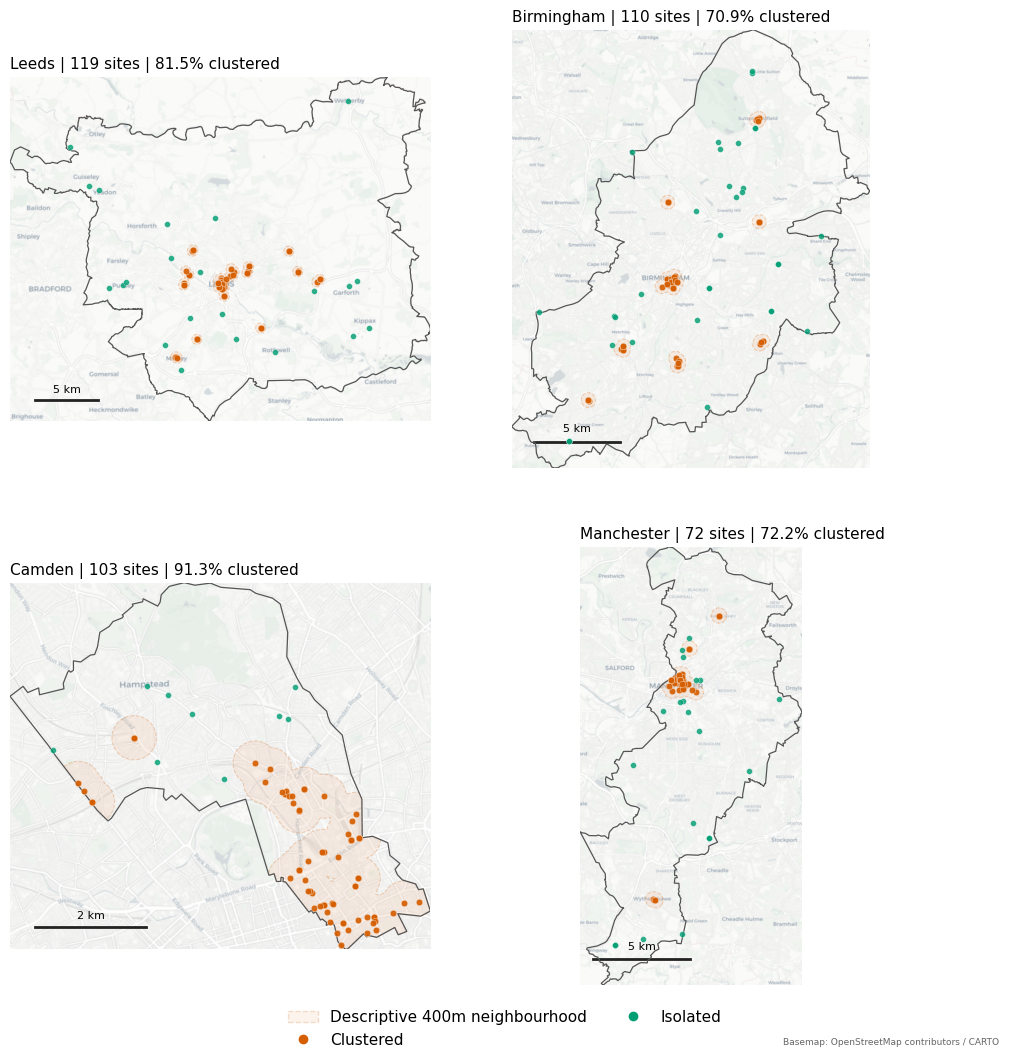

In [19]:
# Spatial map 3: point-level DBSCAN classification.
fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.5))
for ax, name in zip(axes.flat, selected):
    boundary = lads[lads["geocode_name"] == name]
    sub = sites[sites["geocode_name"] == name]
    minx, miny, maxx, maxy = boundary.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    if ctx is not None:
        try:
            ctx.add_basemap(ax, crs=boundary.crs, source=ctx.providers.CartoDB.Positron,
                            attribution=False, reset_extent=True)
            boundary.boundary.plot(ax=ax, color="#555555", linewidth=0.9, zorder=3)
        except Exception as exc:
            print(f"Basemap unavailable for {name}; using LAD outline only: {exc}")
            boundary.plot(ax=ax, color="#F2F3F3", edgecolor="#666666", linewidth=0.8, zorder=1)
    else:
        boundary.plot(ax=ax, color="#F2F3F3", edgecolor="#666666", linewidth=0.8, zorder=1)
    cluster_neighbourhood = sub[sub["clustered"].astype(bool)].geometry.buffer(400).unary_union.intersection(boundary.geometry.unary_union)
    gpd.GeoSeries([cluster_neighbourhood], crs=boundary.crs).plot(
        ax=ax, color="#F3C7A9", alpha=0.25, edgecolor="#D55E00", linewidth=0.75, linestyle="--", zorder=2
    )
    sub[~sub["clustered"].astype(bool)].plot(ax=ax, color="#009E73", markersize=18,
                                             edgecolor="white", linewidth=0.25,
                                             alpha=0.82, zorder=4)
    sub[sub["clustered"].astype(bool)].plot(ax=ax, color="#D55E00", markersize=22,
                                            edgecolor="white", linewidth=0.25,
                                            alpha=0.92, zorder=5)
    share = sub["clustered"].astype(bool).mean() * 100
    ax.set_title(f"{name} | {len(sub)} sites | {share:.1f}% clustered", loc="left", fontsize=11)
    add_scale_bar(ax, 5000 if name != "Camden" else 2000,
                  "5 km" if name != "Camden" else "2 km")
    ax.set_axis_off()
legend = [
    Patch(facecolor="#F3C7A9", edgecolor="#D55E00", linestyle="--", alpha=0.20,
          label="Descriptive 400m neighbourhood"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#D55E00",
           markeredgecolor="none", markersize=7, label="Clustered"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#009E73",
           markeredgecolor="none", markersize=7, label="Isolated"),
]
fig.legend(handles=legend, loc="lower center", ncol=2, frameon=False)
if ctx is not None:
    fig.text(0.985, 0.012, "Basemap: OpenStreetMap contributors / CARTO",
             ha="right", va="bottom", fontsize=6.5, color="#666666")
fig.subplots_adjust(top=0.98, bottom=0.07, hspace=0.18, wspace=0.12)
fig.savefig(FIGURE_OUTPUTS / "main_map_h2_city_dbscan_panels.png")
plt.show()


## 13. Additional city examples for the appendix

/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3576356286.py:23: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = clustered.geometry.buffer(400).unary_union
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3576356286.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = neighbourhood.intersection(boundary.geometry.unary_union)
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3576356286.py:23: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = clustered.geometry.buffer(400).unary_union
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3576356286.py:24: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = neighbourhood.intersection(boundary.geometry.una

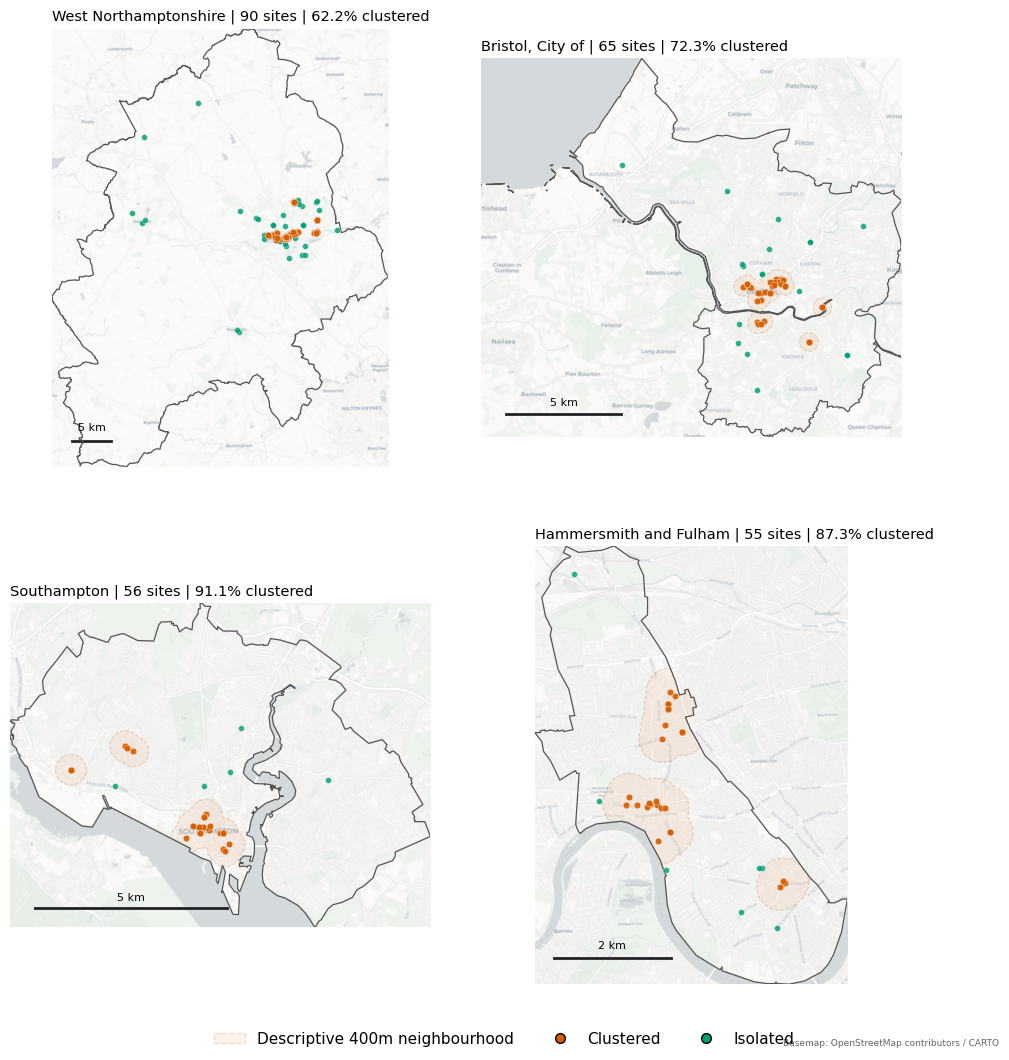

Saved: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs/publication_figures/appendix_map_h2_additional_city_dbscan_panels.png


In [20]:
appendix_cases = [
    "West Northamptonshire", "Bristol, City of",
    "Southampton", "Hammersmith and Fulham",
]

fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.5))
for ax, name in zip(axes.flat, appendix_cases):
    boundary = lads[lads["geocode_name"].eq(name)]
    sub = sites[sites["geocode_name"].eq(name)]
    minx, miny, maxx, maxy = boundary.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    if ctx is not None:
        try:
            ctx.add_basemap(ax, crs=boundary.crs, source=ctx.providers.CartoDB.Positron,
                            attribution=False, reset_extent=True)
        except Exception as exc:
            print(f"Basemap unavailable for {name}: {exc}")
    boundary.boundary.plot(ax=ax, color="#555555", linewidth=0.9, zorder=3)

    clustered = sub[sub["clustered"].astype(bool)]
    neighbourhood = clustered.geometry.buffer(400).unary_union
    neighbourhood = neighbourhood.intersection(boundary.geometry.unary_union)
    gpd.GeoSeries([neighbourhood], crs=boundary.crs).plot(
        ax=ax, color="#F3C7A9", alpha=0.25,
        edgecolor="#D55E00", linewidth=0.75, linestyle="--", zorder=2
    )
    sub[~sub["clustered"].astype(bool)].plot(
        ax=ax, color="#009E73", markersize=18,
        edgecolor="white", linewidth=0.25, alpha=0.82, zorder=4
    )
    clustered.plot(
        ax=ax, color="#D55E00", markersize=22,
        edgecolor="white", linewidth=0.25, alpha=0.92, zorder=5
    )
    share = sub["clustered"].mean() * 100
    ax.set_title(f"{name} | {len(sub)} sites | {share:.1f}% clustered",
                 loc="left", fontsize=10.5)
    length = 2000 if name == "Hammersmith and Fulham" else 5000
    add_scale_bar(ax, length, "2 km" if length == 2000 else "5 km")
    ax.set_axis_off()

legend = [
    Patch(facecolor="#F3C7A9", edgecolor="#D55E00", linestyle="--", alpha=0.20,
          label="Descriptive 400m neighbourhood"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#D55E00",
           markersize=7, label="Clustered"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#009E73",
           markersize=7, label="Isolated"),
]
fig.legend(handles=legend, loc="lower center", ncol=3, frameon=False)
fig.text(0.985, 0.012, "Basemap: OpenStreetMap contributors / CARTO",
         ha="right", fontsize=6.5, color="#666666")
fig.subplots_adjust(top=0.98, bottom=0.07, hspace=0.18, wspace=0.12)
output = FIGURE_OUTPUTS / "appendix_map_h2_additional_city_dbscan_panels.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)


## 14. DBSCAN distance-threshold map
The shaded areas show descriptive neighbourhoods around sites classified as clustered. They are not estimated impact zones.

/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3115405637.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = clustered.geometry.buffer(radius).unary_union
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3115405637.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = neighbourhood.intersection(boundary.geometry.unary_union)
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3115405637.py:9: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = clustered.geometry.buffer(radius).unary_union
/var/folders/dh/9_tnkmpj2qjdmkz_4t0m3z5w0000gn/T/ipykernel_93679/3115405637.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  neighbourhood = neighbourhood.intersection(boundary.geometry

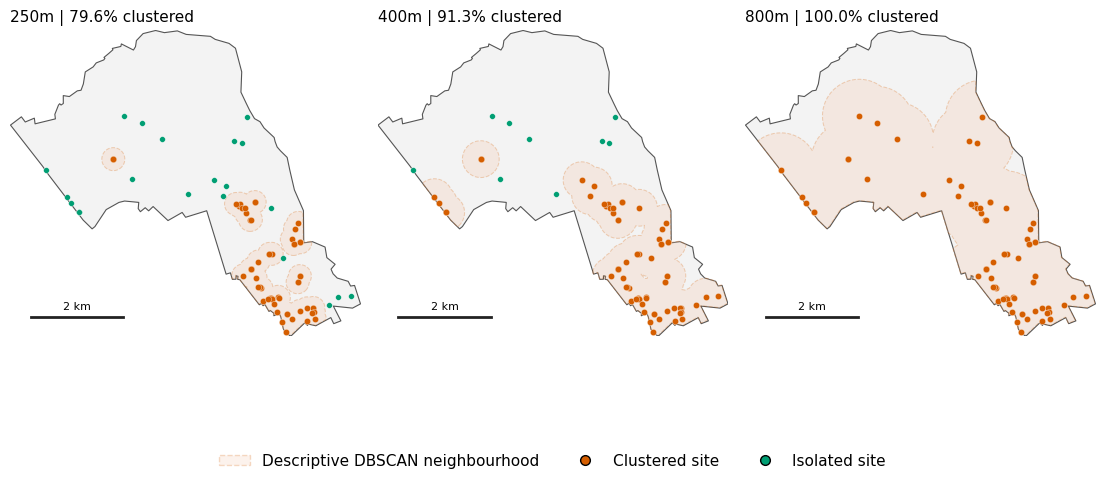

Saved: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs/publication_figures/appendix_map_h2_camden_dbscan_thresholds.png


In [21]:
authority = "Camden"
boundary = lads[lads["geocode_name"].eq(authority)]
fig, axes = plt.subplots(1, 3, figsize=(14.0, 5.4))

for ax, radius in zip(axes, [250, 400, 800]):
    classified = assign_dbscan(g, eps=radius)
    sub = classified[classified["geocode_name"].eq(authority)]
    clustered = sub[sub["clustered"]]
    neighbourhood = clustered.geometry.buffer(radius).unary_union
    neighbourhood = neighbourhood.intersection(boundary.geometry.unary_union)

    boundary.plot(ax=ax, color="#F3F3F3", edgecolor="#555555", linewidth=0.8)
    gpd.GeoSeries([neighbourhood], crs=boundary.crs).plot(
        ax=ax, color="#F3C7A9", alpha=0.25, edgecolor="#D55E00", linewidth=0.75, linestyle="--"
    )
    sub[~sub["clustered"]].plot(
        ax=ax, color="#009E73", markersize=17, edgecolor="white", linewidth=0.25, zorder=3
    )
    clustered.plot(
        ax=ax, color="#D55E00", markersize=21, edgecolor="white", linewidth=0.25, zorder=4
    )
    minx, miny, maxx, maxy = boundary.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)
    share = sub["clustered"].mean() * 100
    ax.set_title(f"{radius}m | {share:.1f}% clustered", loc="left", fontsize=11)
    add_scale_bar(ax, 2000, "2 km")
    ax.set_axis_off()

legend = [
    Patch(facecolor="#F3C7A9", edgecolor="#D55E00", linestyle="--", alpha=0.22,
          label="Descriptive DBSCAN neighbourhood"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#D55E00",
           markersize=7, label="Clustered site"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor="#009E73",
           markersize=7, label="Isolated site"),
]
fig.legend(handles=legend, loc="lower center", ncol=3, frameon=False)
fig.subplots_adjust(top=0.97, bottom=0.13, wspace=0.05)
output = FIGURE_OUTPUTS / "appendix_map_h2_camden_dbscan_thresholds.png"
fig.savefig(output, dpi=300, bbox_inches="tight")
plt.show()
print("Saved:", output)


## 15. City-level quadrat-density map

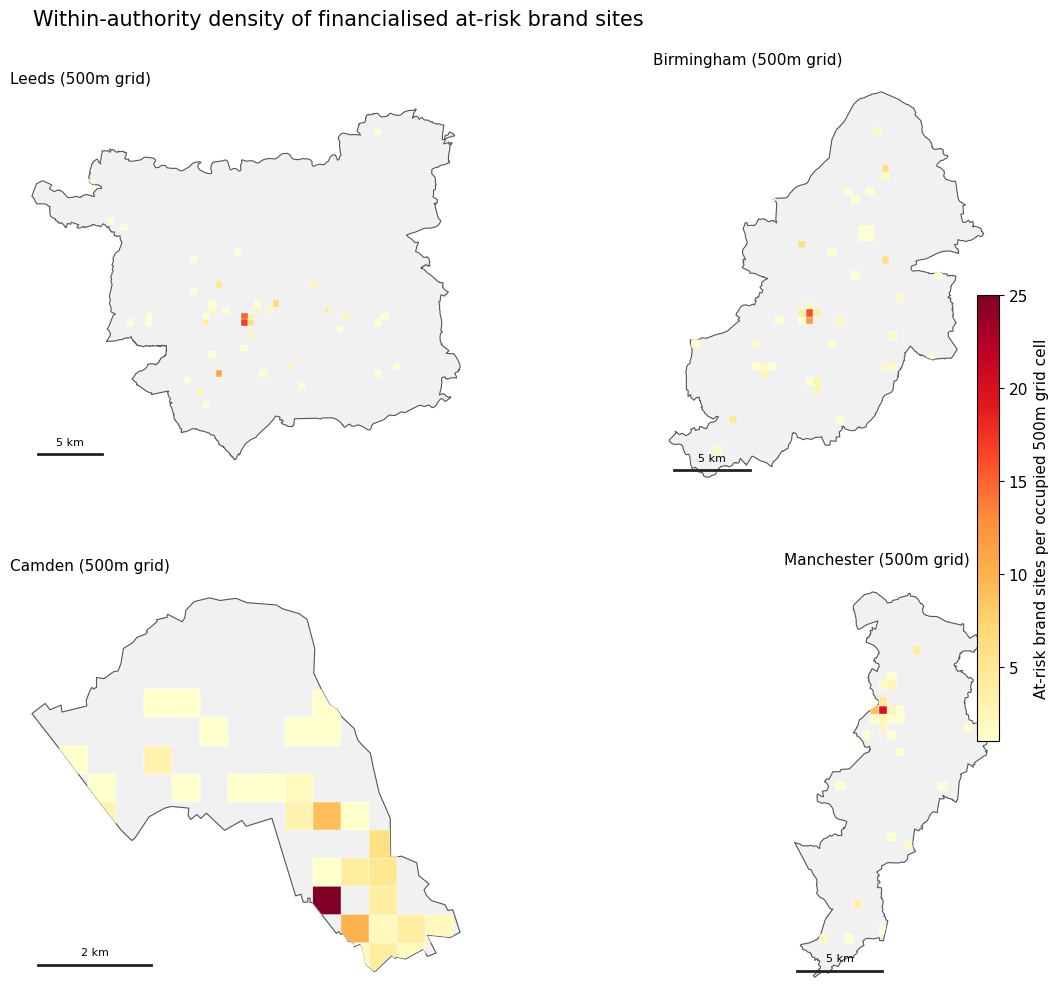

In [22]:
# Spatial map 4: 500m quadrat-density panels. Only occupied cells are coloured.
def occupied_quadrats(points, boundary, cell=500):
    minx, miny, maxx, maxy = boundary.total_bounds
    ix = np.floor((points.geometry.x - minx) / cell).astype(int)
    iy = np.floor((points.geometry.y - miny) / cell).astype(int)
    counts = pd.DataFrame({"ix": ix, "iy": iy}).value_counts().rename("site_count").reset_index()
    counts["geometry"] = [
        box(minx + row.ix*cell, miny + row.iy*cell,
            minx + (row.ix+1)*cell, miny + (row.iy+1)*cell)
        for row in counts.itertuples()
    ]
    cells = gpd.GeoDataFrame(counts, geometry="geometry", crs=points.crs)
    return gpd.clip(cells, boundary)

city_data = {}
for name in selected:
    boundary = lads[lads["geocode_name"] == name]
    city_data[name] = occupied_quadrats(sites[sites["geocode_name"] == name], boundary)
common_max = max(int(frame["site_count"].max()) for frame in city_data.values())
norm = Normalize(vmin=1, vmax=common_max)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 10.5))
for ax, name in zip(axes.flat, selected):
    boundary = lads[lads["geocode_name"] == name]
    boundary.plot(ax=ax, color="#F1F1F1", edgecolor="#555555", linewidth=0.8)
    city_data[name].plot(column="site_count", ax=ax, cmap="YlOrRd", norm=norm,
                         edgecolor="white", linewidth=0.25)
    ax.set_title(f"{name} (500m grid)", loc="left", fontsize=11)
    add_scale_bar(ax, 5000 if name != "Camden" else 2000,
                  "5 km" if name != "Camden" else "2 km")
    ax.set_axis_off()
sm = ScalarMappable(norm=norm, cmap="YlOrRd")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes, fraction=0.025, pad=0.02, shrink=0.78)
cbar.set_label("At-risk brand sites per occupied 500m grid cell")
fig.suptitle("Within-authority density of financialised at-risk brand sites",
             x=0.06, ha="left", fontsize=15)
fig.subplots_adjust(top=0.92, bottom=0.04, left=0.04, right=0.90,
                    hspace=0.18, wspace=0.10)
fig.savefig(FIGURE_OUTPUTS / "main_map_h2_city_quadrat_density_panels.png")
plt.show()

## 16. Moran scatter plots

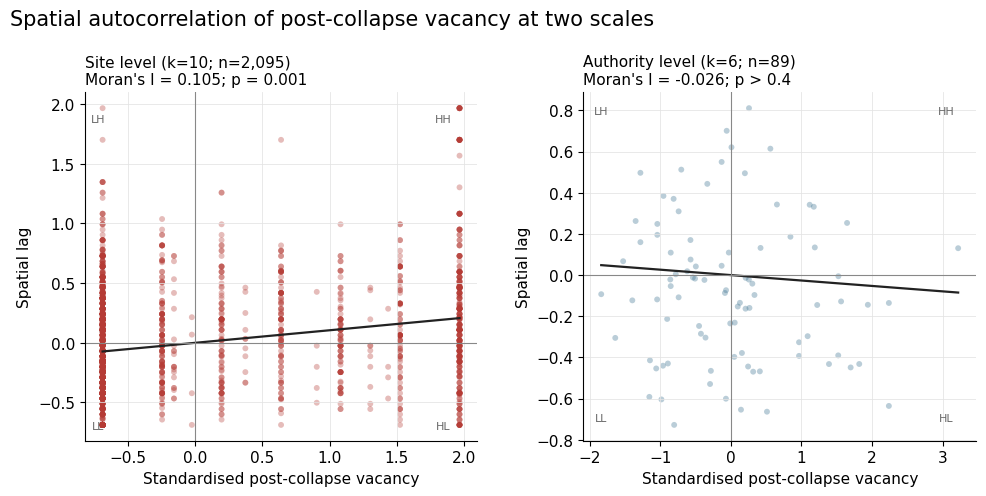

In [23]:
def standardise(values):
    values = np.asarray(values, dtype=float)
    return (values - values.mean()) / values.std(ddof=0)

def moran_panel(ax, values, weights, result, title, colour):
    z = standardise(values)
    wz = lag_spatial(weights, z)
    ax.scatter(z, wz, s=18, color=colour, alpha=0.34, edgecolor="none")
    slope = np.dot(z, wz) / np.dot(z, z)
    xx = np.linspace(z.min(), z.max(), 200)
    ax.plot(xx, slope * xx, color="#222222", linewidth=1.6)
    ax.axhline(0, color="#888888", linewidth=0.8)
    ax.axvline(0, color="#888888", linewidth=0.8)
    ax.set_title(f"{title}\nMoran's I = {result.I:.3f}; " + ("p = 0.001" if result.p_sim <= 0.001 else "p > 0.4"),
                 loc="left", fontsize=11)
    ax.set_xlabel("Standardised post-collapse vacancy")
    ax.set_ylabel("Spatial lag")
    ax.grid(color="#E3E3E3", linewidth=0.55)
    ax.spines[["top", "right"]].set_visible(False)
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
    ax.text(xlim[1]*0.88, ylim[1]*0.88, "HH", ha="center", color="#666666", fontsize=8)
    ax.text(xlim[0]*0.88, ylim[1]*0.88, "LH", ha="center", color="#666666", fontsize=8)
    ax.text(xlim[0]*0.88, ylim[0]*0.88, "LL", ha="center", color="#666666", fontsize=8)
    ax.text(xlim[1]*0.88, ylim[0]*0.88, "HL", ha="center", color="#666666", fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 5.2))
moran_panel(axes[0], sg["post_vac_share"].values, w_site, mi_site,
            f"Site level (k=10; n={len(sg):,})", "#B53B35")
moran_panel(axes[1], auth_moran["post_vac_share"].values, w_auth, mi_auth,
            f"Authority level (k=6; n={len(auth_moran):,})", "#376F8D")
fig.suptitle("Spatial autocorrelation of post-collapse vacancy at two scales",
             x=0.06, ha="left", fontsize=15)
fig.subplots_adjust(top=0.82, bottom=0.15, wspace=0.27)
fig.savefig(FIGURE_OUTPUTS / "main_figure_h2_two_scale_moran_scatter.png")
plt.show()


## 17. Descriptive correlation heatmap

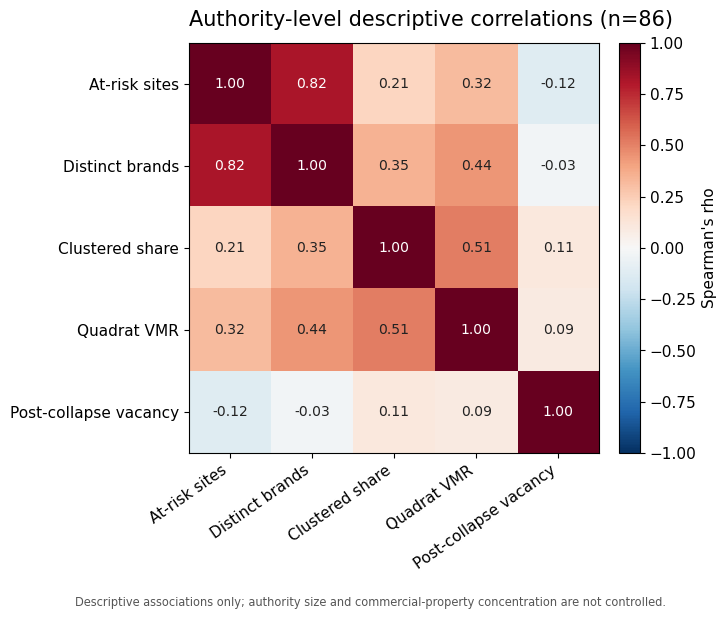

In [24]:
# Appendix C: descriptive authority-level Spearman correlation heatmap.
exposure_metrics = (sites.groupby("geocode_name")
                    .agg(at_risk_sites=("uarn", "nunique"),
                         distinct_brands=("brand", "nunique"),
                         clustered_share=("clustered", "mean"))
                    .reset_index())
vmr_metrics = q[["authority", "VMR_observed"]].rename(columns={"authority": "geocode_name"})
vacancy_metrics = (sg.groupby("geocode_name")["post_vac_share"]
                   .mean().rename("post_vacancy_share").reset_index())
authority_metrics = (exposure_metrics.merge(vmr_metrics, on="geocode_name", how="inner")
                     .merge(vacancy_metrics, on="geocode_name", how="inner"))
metric_columns = ["at_risk_sites", "distinct_brands", "clustered_share",
                  "VMR_observed", "post_vacancy_share"]
corr = authority_metrics[metric_columns].corr(method="spearman")
corr.to_csv(FIGURE_OUTPUTS / "appendix_c_authority_spearman_correlations.csv")

labels = ["At-risk sites", "Distinct brands", "Clustered share",
          "Quadrat VMR", "Post-collapse vacancy"]
fig, ax = plt.subplots(figsize=(7.4, 6.2))
image = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels=labels, rotation=35, ha="right")
ax.set_yticks(range(len(labels)), labels=labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center",
                color="white" if abs(value) > 0.55 else "#222222", fontsize=10)
cbar = fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Spearman's rho")
ax.set_title(f"Authority-level descriptive correlations (n={len(authority_metrics)})",
             loc="left", pad=12)
fig.text(0.11, 0.012,
         "Descriptive associations only; authority size and commercial-property concentration are not controlled.",
         fontsize=8.2, color="#555555")
fig.tight_layout(rect=[0, 0.04, 1, 1])
fig.savefig(FIGURE_OUTPUTS / "appendix_c_authority_spearman_heatmap.png")
plt.show()

The heatmap uses the 86 authorities that satisfy the quadrat criteria. Its
exposure-clustering correlation therefore differs from the 89-authority value
shown in the main authority-distribution figure.


## 18. Final tables

In [25]:
display(pd.read_csv(OUT / "finding_h2_quadrat_vmr_csr.csv").head(12))
display(pd.read_csv(OUT / "finding_h2_morans_i_two_scales.csv"))
print("Outputs:", OUT)

,authority,n_sites,quadrats,VMR_observed,VMR_CSR_mean,p_value,clustered_p<0.05
0,Leeds,119,2112,6.641,1.000,0.001,True
1,Birmingham,110,1419,7.450,1.000,0.001,True
2,Camden,103,140,7.060,1.046,0.001,True
3,West Northamptonshire,90,3127,4.149,1.001,0.001,True
4,Manchester,72,630,7.525,1.008,0.001,True
5,"Bristol, City of",65,420,6.538,1.001,0.001,True
6,"Bournemouth, Christchurch and Poole",64,400,3.559,1.000,0.001,True
7,Somerset,63,12877,3.344,1.001,0.001,True
8,Cheshire West and Chester,61,1682,8.734,1.002,0.001,True
9,Wiltshire,60,10125,4.561,1.000,0.001,True


,scale,n,Moran's I,E[I],p (999 perm),significant p<0.05
0,Site level (k=10),2095,0.1053,-0.0005,0.001,True
1,Authority level (k=6),89,-0.0263,-0.0114,0.451,False


Outputs: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs


### Appendix B3: Camden cluster envelopes


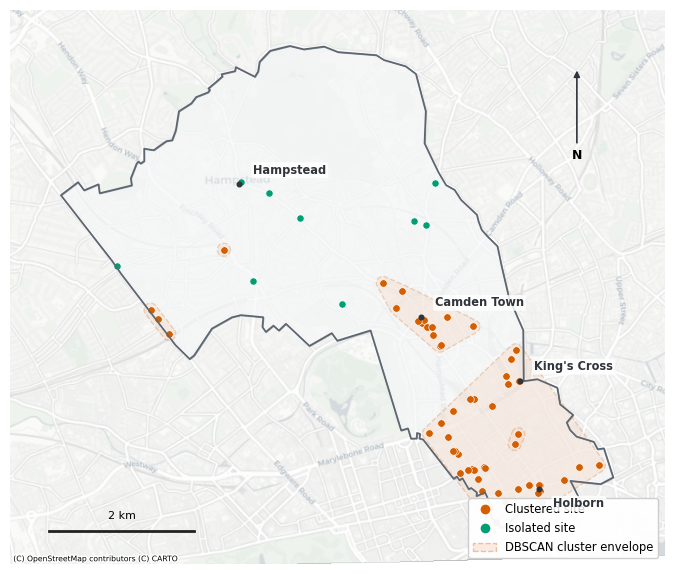

Saved: /Users/homanchan/Documents/GitHub/financialised-high-street-vacancy/outputs/publication_figures/appendix_b3_camden_detailed_cluster_map.png


In [26]:
from shapely.geometry import MultiPoint
from pyproj import Transformer

cluster_colour = "#D55E00"
isolated_colour = "#009E73"
envelope_fill = "#F3C7A9"

camden = sites[sites["geocode_name"].eq("Camden")].copy()
camden_boundary = lads[lads["geocode_name"].eq("Camden")]
clustered = camden[camden["clustered"].astype(bool)].copy()
isolated = camden[~camden["clustered"].astype(bool)].copy()

hulls = []
for cluster_id, group in clustered.groupby("cluster_id"):
    if len(group) >= 3:
        hulls.append({
            "cluster_id": cluster_id,
            "geometry": MultiPoint(list(group.geometry)).convex_hull.buffer(90),
        })
hulls = gpd.GeoDataFrame(hulls, geometry="geometry", crs=sites.crs)

fig, ax = plt.subplots(figsize=(9.2, 7.2))
camden_boundary.plot(ax=ax, facecolor="#F6F7F8", edgecolor="#5D6670", linewidth=1.0, alpha=0.70)
if ctx is not None:
    ctx.add_basemap(ax, crs=camden_boundary.crs, source=ctx.providers.CartoDB.Positron,
                    zoom=13, attribution_size=5.5, zorder=0)
hulls.plot(ax=ax, facecolor=envelope_fill, edgecolor=cluster_colour,
           linewidth=1.0, linestyle="--", alpha=0.24, zorder=2)
clustered.plot(ax=ax, color=cluster_colour, edgecolor="white", linewidth=0.45,
               markersize=29, zorder=4)
isolated.plot(ax=ax, color=isolated_colour, edgecolor="white", linewidth=0.45,
              markersize=27, zorder=4)
camden_boundary.boundary.plot(ax=ax, color="#5D6670", linewidth=1.15, zorder=5)
minx, miny, maxx, maxy = camden_boundary.total_bounds
ax.set_xlim(minx - 700, maxx + 700)
ax.set_ylim(miny - 500, maxy + 500)
ax.set_aspect("equal")
ax.set_axis_off()

transformer = Transformer.from_crs(4326, 27700, always_xy=True)
places = {
    "Hampstead": (-0.1780, 51.5560, 10, 8),
    "Camden Town": (-0.1426, 51.5390, 10, 8),
    "King's Cross": (-0.1233, 51.5308, 10, 8),
    "Holborn": (-0.1200, 51.5174, 10, -13),
}
for label, (lon, lat, dx, dy) in places.items():
    x, y = transformer.transform(lon, lat)
    ax.scatter([x], [y], s=11, color="#30343B", zorder=6)
    ax.annotate(label, (x, y), xytext=(dx, dy), textcoords="offset points",
                fontsize=8.2, weight="semibold", color="#30343B",
                bbox={"boxstyle": "round,pad=0.16", "fc": "white", "ec": "none", "alpha": 0.84},
                zorder=7)
add_scale_bar(ax, 2000, "2 km")
ax.annotate("N", xy=(maxx - 500, maxy - 300), xytext=(maxx - 500, maxy - 1500),
            ha="center", va="center", fontsize=9, weight="bold",
            arrowprops={"arrowstyle": "-|>", "color": "#30343B", "lw": 1.2}, zorder=8)

legend = [
    Line2D([0], [0], marker="o", color="none", markerfacecolor=cluster_colour,
           markeredgecolor="white", markersize=8, label="Clustered site"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=isolated_colour,
           markeredgecolor="white", markersize=8, label="Isolated site"),
    Patch(facecolor=envelope_fill, edgecolor=cluster_colour, linestyle="--",
          alpha=0.35, label="DBSCAN cluster envelope"),
]
ax.legend(handles=legend, loc="lower right", frameon=True, framealpha=0.94,
          facecolor="white", edgecolor="#CCCCCC", fontsize=8.3)
output = FIGURE_OUTPUTS / "appendix_b3_camden_detailed_cluster_map.png"
fig.savefig(output, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()
print("Saved:", output)
